# Anemia Prediction using Random Forest Classification & SHAP
## Part 1: Project Introduction
Predicting `Result` from `Gender`, `Hemoglobin`, `MCH`, `MCHC`, `MCV` using Random Forest & SHAP Explainable AI.
> **Disclaimer**: Educational/research project only. Not a medical diagnostic tool.


## Part 2: Import Libraries


In [1]:
# Install required packages directly in the active Jupyter kernel if missing
!pip install -q shap seaborn scikit-learn pandas numpy joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib
import shap
import os
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100

print("All required libraries imported successfully.")



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All required libraries imported successfully.


## Part 3: Load Dataset


In [2]:
# Load dataset
data_path = "anemia.csv"
assert os.path.exists(data_path), f"Dataset file not found at {data_path}"

df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)


Dataset Shape: 1421 rows, 6 columns

--- First 5 Rows ---


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0



--- Last 5 Rows ---


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
1416,0,10.6,25.4,28.2,82.9,1
1417,1,12.1,28.3,30.4,86.9,1
1418,1,13.1,17.7,28.1,80.7,1
1419,0,14.3,16.2,29.5,95.2,0
1420,0,11.8,21.2,28.4,98.1,1



--- Column Names ---
['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Result']

--- Data Types ---
Gender          int64
Hemoglobin    float64
MCH           float64
MCHC          float64
MCV           float64
Result          int64
dtype: object


## Part 4: Data Understanding


--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB

--- Summary Statistics ---


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000



--- Missing Values Count ---
Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64

Duplicate Rows Count: 887

--- Unique Values Count Per Column ---
Gender: 2 unique values
Hemoglobin: 81 unique values
MCH: 136 unique values
MCHC: 48 unique values
MCV: 262 unique values
Result: 2 unique values

--- Target Class Distribution ---
        Count  Percentage (%)
Result                       
0         801       56.368754
1         620       43.631246


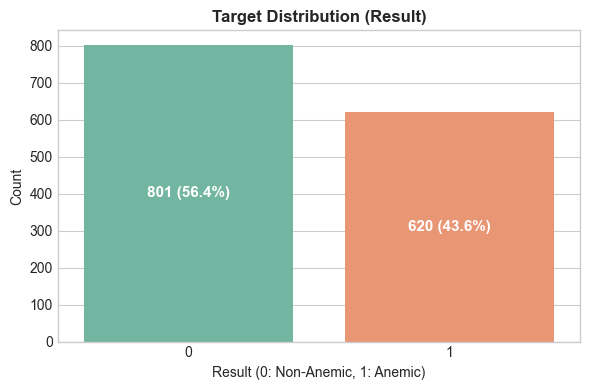

In [3]:
print("--- Dataframe Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print(f"\nDuplicate Rows Count: {df.duplicated().sum()}")

print("\n--- Unique Values Count Per Column ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n--- Target Class Distribution ---")
target_counts = df["Result"].value_counts()
target_props = df["Result"].value_counts(normalize=True) * 100
target_df = pd.DataFrame({"Count": target_counts, "Percentage (%)": target_props})
print(target_df)

# Target Distribution Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Result", palette="Set2")
plt.title("Target Distribution (Result)", fontsize=12, fontweight='bold')
plt.xlabel("Result (0: Non-Anemic, 1: Anemic)")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


## Part 5: Data Validation & Deduplication


In [4]:
# Deduplication to prevent data leakage across train/test splits
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Deduplicated Shape: {df_clean.shape[0]} unique rows, {df_clean.shape[1]} columns.")

# Numerical Physiological Range Check
valid_ranges = {
    'Hemoglobin': (5.0, 20.0),
    'MCH': (10.0, 40.0),
    'MCHC': (20.0, 40.0),
    'MCV': (50.0, 120.0),
    'Gender': (0, 1),
    'Result': (0, 1)
}

print("\n--- Feature Range Check ---")
for col, (min_val, max_val) in valid_ranges.items():
    actual_min = df_clean[col].min()
    actual_max = df_clean[col].max()
    is_valid = (actual_min >= min_val) and (actual_max <= max_val)
    status = "VALID" if is_valid else "OUT OF BOUNDS"
    print(f"Feature: {col:<12} | Min: {actual_min:>5.1f} | Max: {actual_max:>5.1f} | Status: {status}")


Deduplicated Shape: 534 unique rows, 6 columns.

--- Feature Range Check ---
Feature: Hemoglobin   | Min:   6.6 | Max:  16.9 | Status: VALID
Feature: MCH          | Min:  16.0 | Max:  30.0 | Status: VALID
Feature: MCHC         | Min:  27.8 | Max:  32.5 | Status: VALID
Feature: MCV          | Min:  69.4 | Max: 101.6 | Status: VALID
Feature: Gender       | Min:   0.0 | Max:   1.0 | Status: VALID
Feature: Result       | Min:   0.0 | Max:   1.0 | Status: VALID


## Part 6: Exploratory Data Analysis (EDA)


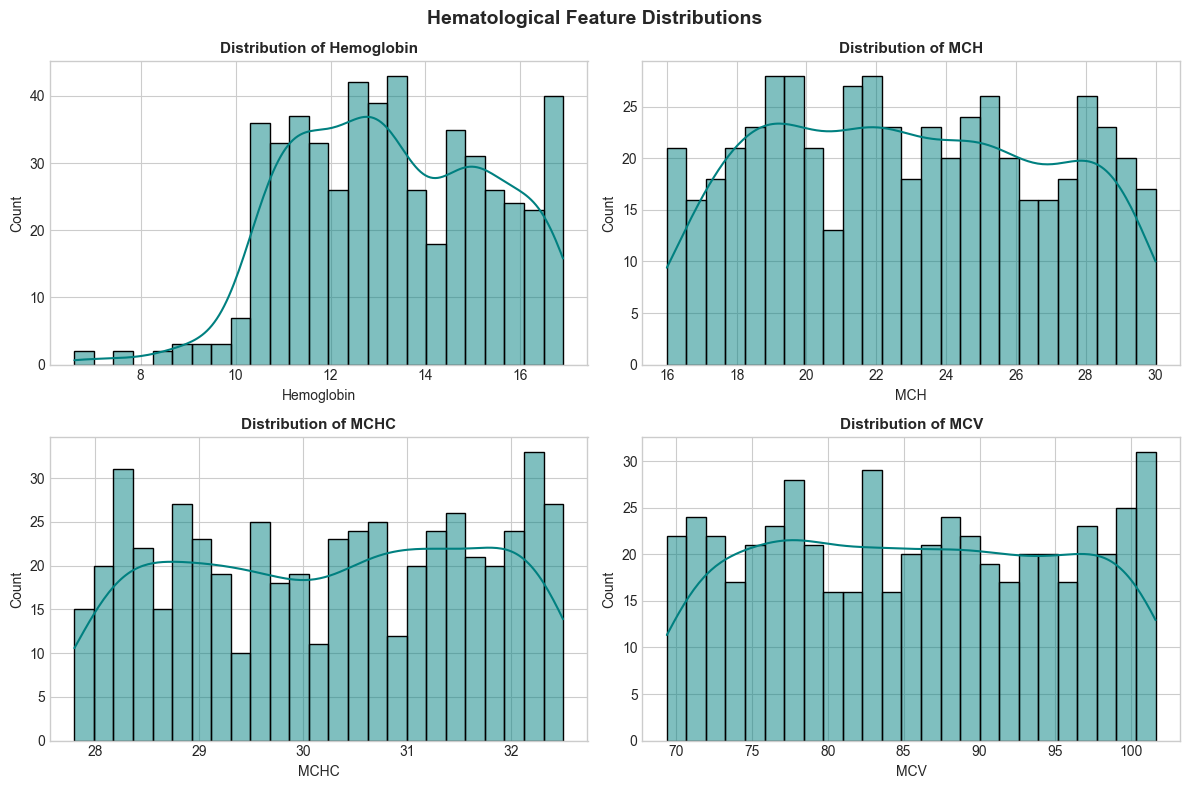

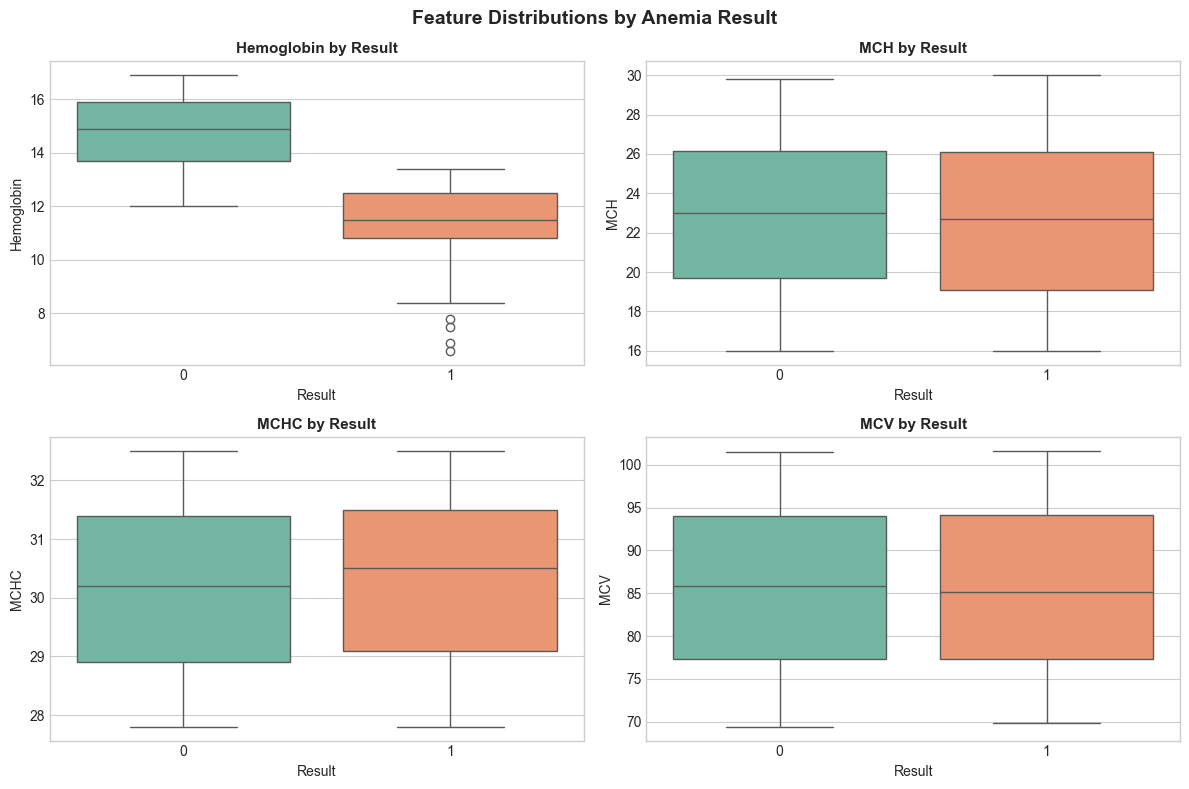

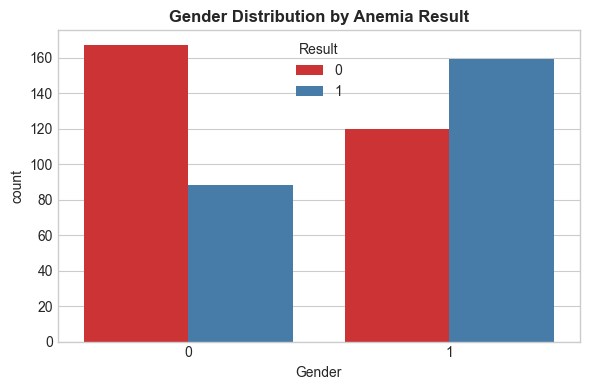

In [5]:
num_features = ['Hemoglobin', 'MCH', 'MCHC', 'MCV']

# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal', bins=25)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')

plt.suptitle("Hematological Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplots by Result
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df_clean, x='Result', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Result', fontsize=11, fontweight='bold')

plt.suptitle("Feature Distributions by Anemia Result", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gender vs Result
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Gender', hue='Result', palette='Set1')
plt.title("Gender Distribution by Anemia Result", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 7: Correlation Analysis


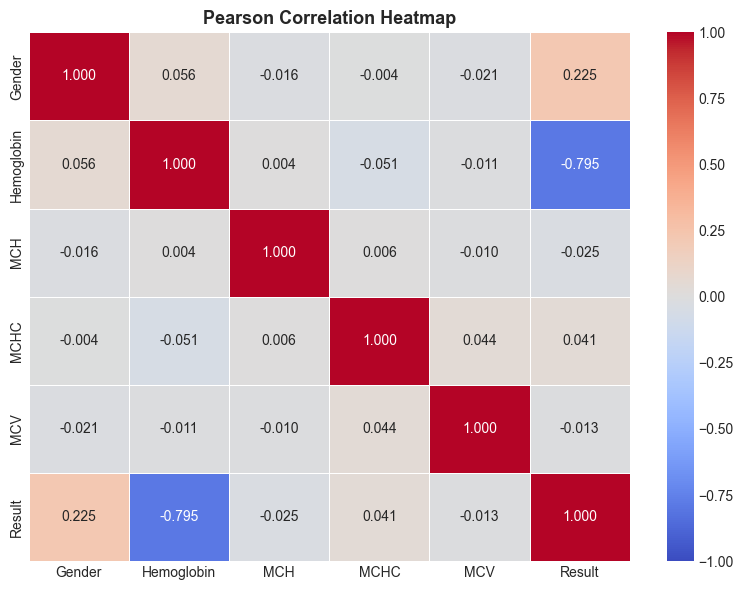

--- Feature Correlation with Target (Result) ---
Result        1.000000
Gender        0.225200
MCHC          0.041229
MCV          -0.013233
MCH          -0.025098
Hemoglobin   -0.794549
Name: Result, dtype: float64


In [6]:
# Pearson Correlation Heatmap
corr_matrix = df_clean.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pearson Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- Feature Correlation with Target (Result) ---")
print(corr_matrix["Result"].sort_values(ascending=False))


## Part 8: Data Preprocessing


In [7]:
# Separate features and target
X = df_clean.drop("Result", axis=1)
y = df_clean["Result"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Features list:", X.columns.tolist())


Feature matrix shape: (534, 5)
Target vector shape: (534,)
Features list: ['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV']


## Part 9: Train / Test Split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size:  {X_test.shape[0]} samples\n")

print("--- Training Class Distribution ---")
print(y_train.value_counts(normalize=True).map("{:.2%}".format))

print("\n--- Testing Class Distribution ---")
print(y_test.value_counts(normalize=True).map("{:.2%}".format))


Training Set Size: 427 samples
Testing Set Size:  107 samples

--- Training Class Distribution ---
Result
0    53.63%
1    46.37%
Name: proportion, dtype: object

--- Testing Class Distribution ---
Result
0    54.21%
1    45.79%
Name: proportion, dtype: object


## Part 10: Baseline Random Forest Model


In [9]:
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train Baseline Model
baseline_rf.fit(X_train, y_train)

print("Baseline Random Forest model trained successfully.")


Baseline Random Forest model trained successfully.


## Part 11: Baseline Predictions


In [10]:
y_pred_base = baseline_rf.predict(X_test)
y_prob_base = baseline_rf.predict_proba(X_test)[:, 1]

pred_df = pd.DataFrame({
    'Actual Result': y_test.values[:10],
    'Predicted Result': y_pred_base[:10],
    'Probability (Anemia)': np.round(y_prob_base[:10], 4)
})
display(pred_df)


,Actual Result,Predicted Result,Probability (Anemia)
0,0,0,0.005
1,1,1,0.980
2,1,1,0.965
3,0,0,0.035
4,1,1,0.905
5,0,0,0.015
6,1,1,0.990
7,1,1,0.925
8,1,1,0.995
9,0,0,0.200


## Part 12: Baseline Model Evaluation


In [11]:
base_acc = accuracy_score(y_test, y_pred_base)
base_prec = precision_score(y_test, y_pred_base)
base_rec = recall_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, y_prob_base)

print("--- Baseline Model Performance Metrics ---")
print(f"Accuracy:  {base_acc:.4f}")
print(f"Precision: {base_prec:.4f}")
print(f"Recall:    {base_rec:.4f}")
print(f"F1-Score:  {base_f1:.4f}")
print(f"ROC-AUC:   {base_auc:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_base, target_names=["Non-Anemic", "Anemic"]))


--- Baseline Model Performance Metrics ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- Classification Report ---
              precision    recall  f1-score   support

  Non-Anemic       1.00      1.00      1.00        58
      Anemic       1.00      1.00      1.00        49

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107



## Part 13: Confusion Matrix


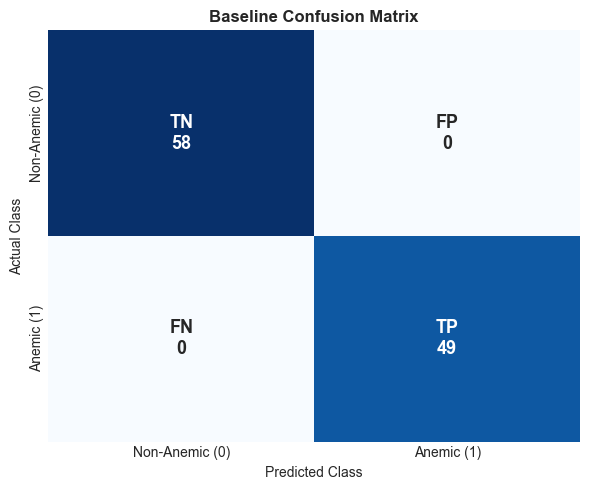

TN: 58 | FP: 0 | FN: 0 | TP: 49


In [12]:
cm_base = confusion_matrix(y_test, y_pred_base)
tn, fp, fn, tp = cm_base.ravel()

labels = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Non-Anemic (0)", "Anemic (1)"],
            yticklabels=["Non-Anemic (0)", "Anemic (1)"],
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Baseline Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")


## Part 14: Receiver Operating Characteristic (ROC) Curve


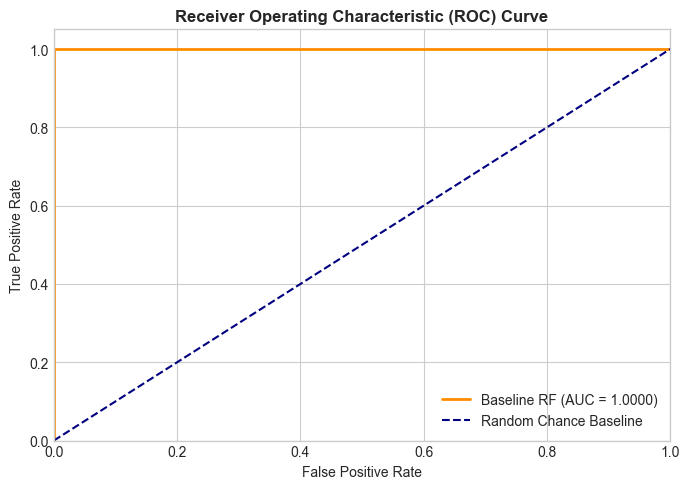

In [13]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, color='darkorange', lw=2, label=f'Baseline RF (AUC = {base_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Part 15: Baseline Random Forest Feature Importance


--- Random Forest Gini Feature Importances ---


,Feature,Importance
1,Hemoglobin,0.827550
0,Gender,0.084857
4,MCV,0.033517
2,MCH,0.028852
3,MCHC,0.025224


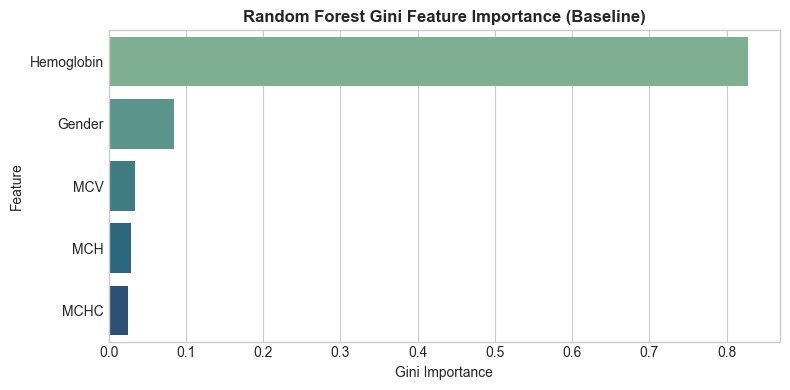

In [14]:
importances = baseline_rf.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Random Forest Gini Feature Importances ---")
display(fi_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Gini Feature Importance (Baseline)", fontsize=12, fontweight='bold')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=300)
plt.show()


## Part 16: Hyperparameter Tuning


In [15]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on training set only
grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully.")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV completed successfully.


## Part 17: Select Best Model


In [16]:
print("--- Optimal Hyperparameters ---")
for param, val in grid_search.best_params_.items():
    print(f"{param:<20}: {val}")

print(f"\nBest Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Extract best estimator
tuned_rf = grid_search.best_estimator_


--- Optimal Hyperparameters ---
max_depth           : None
max_features        : sqrt
min_samples_leaf    : 1
min_samples_split   : 2
n_estimators        : 100

Best Cross-Validation F1-Score: 0.9975


## Part 18: Final Model Evaluation


In [17]:
y_pred_tuned = tuned_rf.predict(X_test)
y_prob_tuned = tuned_rf.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

comp_df = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Tuned Random Forest'],
    'Accuracy': [base_acc, tuned_acc],
    'Precision': [base_prec, tuned_prec],
    'Recall': [base_rec, tuned_rec],
    'F1-Score': [base_f1, tuned_f1],
    'ROC-AUC': [base_auc, tuned_auc]
})

print("--- Model Performance Comparison ---")
display(comp_df)

print("\n--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Anemic", "Anemic"]))


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Random Forest,1.000000,1.00,1.0,1.000000,1.0
1,Tuned Random Forest,0.990654,0.98,1.0,0.989899,1.0



--- Tuned Classification Report ---
              precision    recall  f1-score   support

  Non-Anemic       1.00      0.98      0.99        58
      Anemic       0.98      1.00      0.99        49

    accuracy                           0.99       107
   macro avg       0.99      0.99      0.99       107
weighted avg       0.99      0.99      0.99       107



## Part 19: Stratified Cross-Validation


In [18]:
cv_scores = cross_val_score(tuned_rf, X_train, y_train, cv=cv, scoring='f1')

print("--- 5-Fold Stratified Cross-Validation F1 Scores ---")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold}: {score:.4f}")

print(f"\nMean CV F1 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


--- 5-Fold Stratified Cross-Validation F1 Scores ---
Fold 1: 0.9877
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000

Mean CV F1 Score: 0.9975
Standard Deviation: 0.0049


## Part 20: Final Model Designation


In [19]:
# Final model designation
final_model = tuned_rf

print("Final Random Forest model successfully designated.")
print("Model Configuration:", final_model)


Final Random Forest model successfully designated.
Model Configuration: RandomForestClassifier(random_state=42)


## Part 21: SHAP Explainability Overview


## Part 22: Create SHAP Explainer


In [20]:
# Instantiate TreeExplainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values for test set
shap_values = explainer(X_test)

print("SHAP TreeExplainer initialized and SHAP values computed.")


SHAP TreeExplainer initialized and SHAP values computed.


## Part 23: SHAP Value Inspection


In [21]:
print(f"SHAP Values Object Type: {type(shap_values)}")

if hasattr(shap_values, 'shape'):
    print(f"SHAP Values Matrix Shape: {shap_values.shape}")
elif hasattr(shap_values, 'values'):
    print(f"SHAP Values Matrix Shape: {shap_values.values.shape}")

print(f"Feature Names in SHAP Explanation: {X_test.columns.tolist()}")

# Extract class-1 SHAP values
if len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values.values[:, :, 1]
    exp_obj_class1 = shap.Explanation(
        values=shap_vals_class1,
        base_values=shap_values.base_values[:, 1] if len(shap_values.base_values.shape) > 1 else shap_values.base_values,
        data=X_test.values,
        feature_names=X_test.columns.tolist()
    )
else:
    exp_obj_class1 = shap_values

print("SHAP class-1 explanation object successfully structured.")


SHAP Values Object Type: <class 'shap._explanation.Explanation'>
SHAP Values Matrix Shape: (107, 5, 2)
Feature Names in SHAP Explanation: ['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV']
SHAP class-1 explanation object successfully structured.


## Part 24: SHAP Global Feature Importance


--- Feature Importance Comparison ---


,Feature,Mean Absolute SHAP,Random Forest Gini Importance
0,Hemoglobin,0.385033,0.824698
1,Gender,0.104582,0.088578
2,MCH,0.011404,0.026775
3,MCV,0.011317,0.032187
4,MCHC,0.009562,0.027762


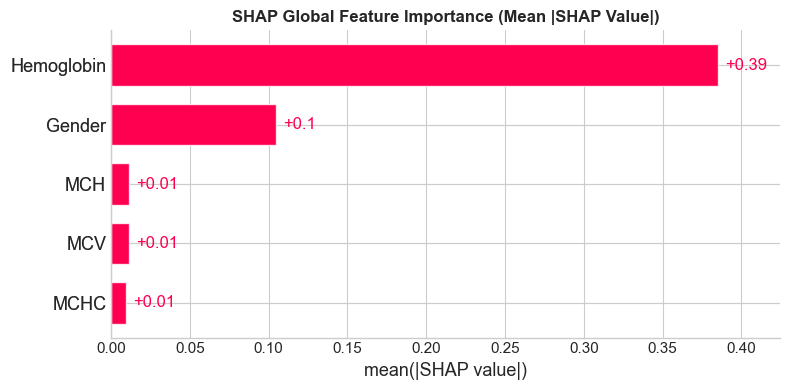

In [22]:
mean_abs_shap = np.abs(exp_obj_class1.values).mean(axis=0)

shap_fi_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Absolute SHAP': mean_abs_shap,
    'Random Forest Gini Importance': final_model.feature_importances_
}).sort_values(by='Mean Absolute SHAP', ascending=False).reset_index(drop=True)

print("--- Feature Importance Comparison ---")
display(shap_fi_df)

# Plot SHAP Bar Plot
plt.figure(figsize=(8, 4))
shap.plots.bar(exp_obj_class1, show=False)
plt.title("SHAP Global Feature Importance (Mean |SHAP Value|)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300)
plt.show()


## Part 25: SHAP Summary / Beeswarm Plot


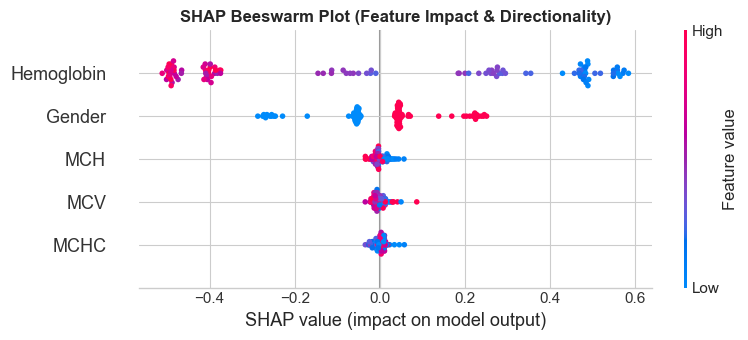

In [23]:
plt.figure(figsize=(9, 5))
shap.plots.beeswarm(exp_obj_class1, show=False)
plt.title("SHAP Beeswarm Plot (Feature Impact & Directionality)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()


## Part 26: SHAP Dependence Plots


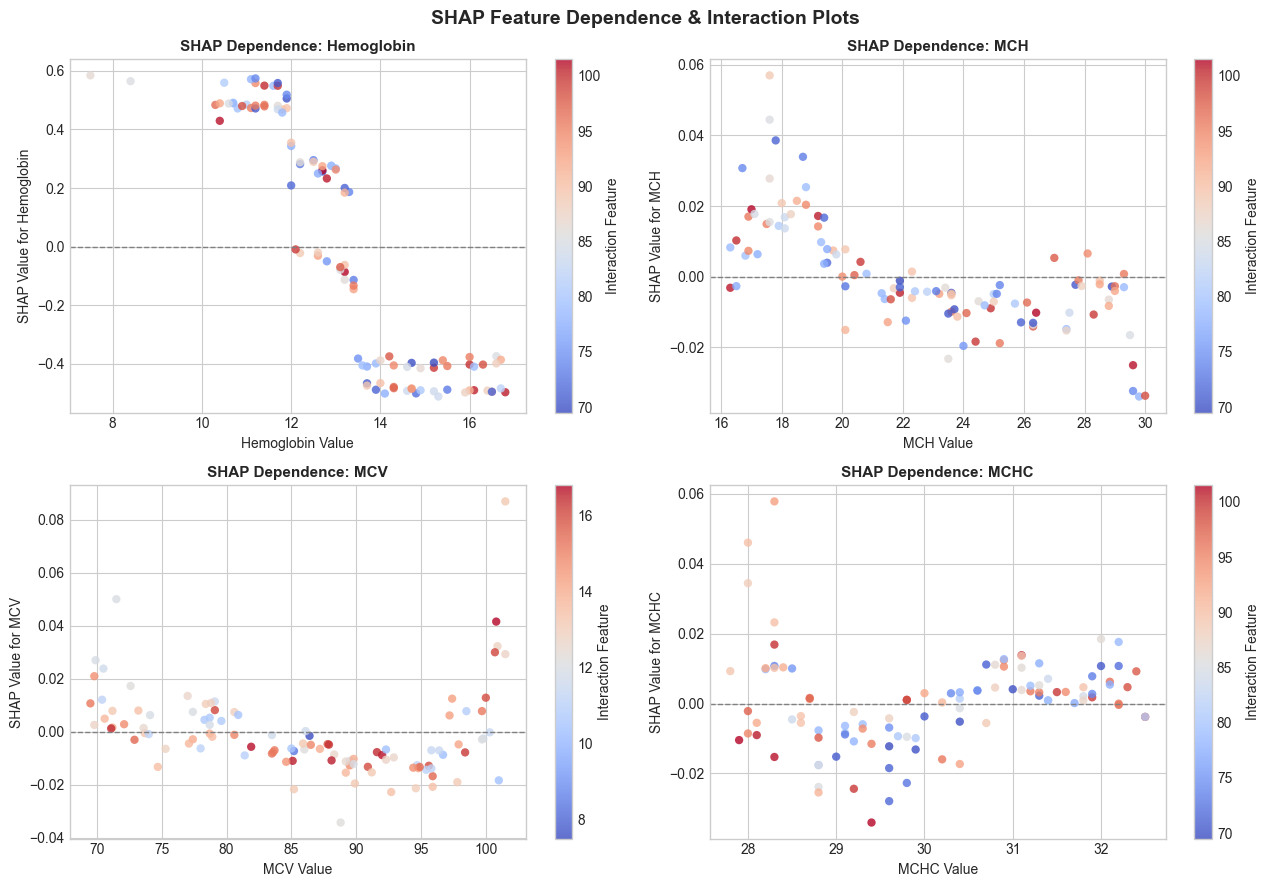

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
top_features = ['Hemoglobin', 'MCH', 'MCV', 'MCHC']

for i, feat in enumerate(top_features):
    ax = axes[i // 2, i % 2]
    feat_idx = X_test.columns.get_loc(feat)
    x_vals = X_test[feat].values
    y_vals = exp_obj_class1.values[:, feat_idx]
    
    scatter = ax.scatter(x_vals, y_vals, c=X_test['MCV'].values if feat != 'MCV' else X_test['Hemoglobin'].values,
                         cmap='coolwarm', alpha=0.8, edgecolors='none')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{feat} Value')
    ax.set_ylabel(f'SHAP Value for {feat}')
    fig.colorbar(scatter, ax=ax, label='Interaction Feature')

plt.suptitle("SHAP Feature Dependence & Interaction Plots", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=300)
plt.show()


## Part 27: Local SHAP Explanations (Waterfall Plots)


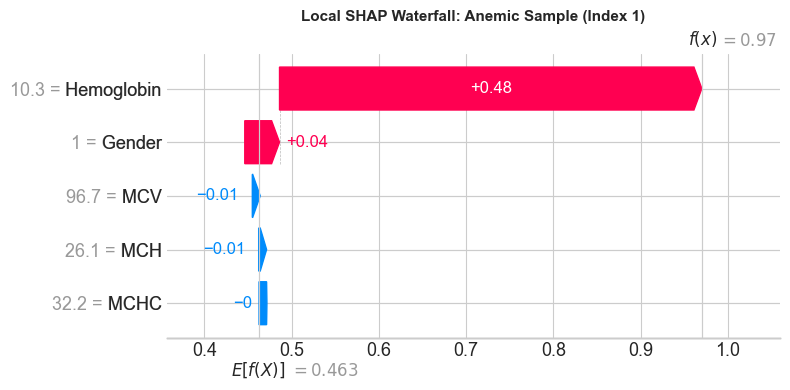

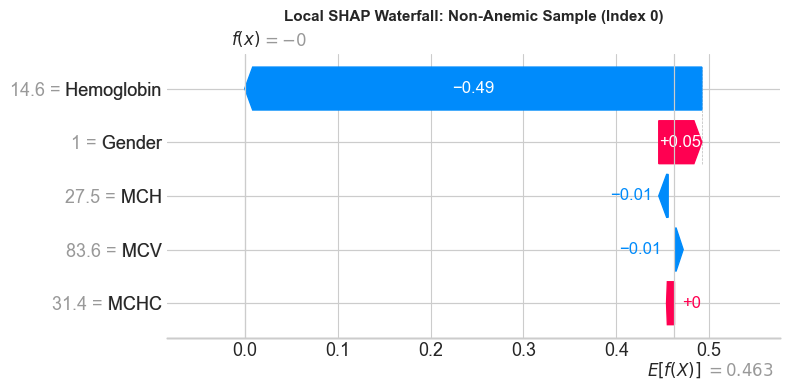

In [25]:
# Sample selection
anemic_indices = np.where((y_test.values == 1) & (y_pred_tuned == 1))[0]
non_anemic_indices = np.where((y_test.values == 0) & (y_pred_tuned == 0))[0]

sample_pos_idx = anemic_indices[0] if len(anemic_indices) > 0 else 0
sample_neg_idx = non_anemic_indices[0] if len(non_anemic_indices) > 0 else 1

# Waterfall plot: Anemic Sample
plt.figure(figsize=(8, 5))
shap.plots.waterfall(exp_obj_class1[sample_pos_idx], show=False)
plt.title(f"Local SHAP Waterfall: Anemic Sample (Index {sample_pos_idx})", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Waterfall plot: Non-Anemic Sample
plt.figure(figsize=(8, 5))
shap.plots.waterfall(exp_obj_class1[sample_neg_idx], show=False)
plt.title(f"Local SHAP Waterfall: Non-Anemic Sample (Index {sample_neg_idx})", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 28: Individual Prediction Explanations Breakdown


In [26]:
def explain_individual_sample(sample_idx):
    sample_feat = X_test.iloc[sample_idx]
    actual_cls = y_test.iloc[sample_idx]
    pred_cls = y_pred_tuned[sample_idx]
    prob_anemia = y_prob_tuned[sample_idx]
    sample_shap = exp_obj_class1.values[sample_idx]
    
    print(f"==================================================")
    print(f"EXPLANATION REPORT FOR TEST SAMPLE INDEX {sample_idx}")
    print(f"==================================================")
    print(f"Actual Class:        {'Anemic (1)' if actual_cls == 1 else 'Non-Anemic (0)'}")
    print(f"Predicted Class:     {'Anemic (1)' if pred_cls == 1 else 'Non-Anemic (0)'}")
    print(f"Predicted Prob:      {prob_anemia:.4f}")
    
    breakdown = pd.DataFrame({
        'Feature Value': sample_feat,
        'SHAP Contribution': sample_shap
    }).sort_values(by='SHAP Contribution', key=abs, ascending=False)
    
    display(breakdown)

explain_individual_sample(sample_pos_idx)
explain_individual_sample(sample_neg_idx)


EXPLANATION REPORT FOR TEST SAMPLE INDEX 1
Actual Class:        Anemic (1)
Predicted Class:     Anemic (1)
Predicted Prob:      0.9700


,Feature Value,SHAP Contribution
Hemoglobin,10.3,0.483959
Gender,1.0,0.039822
MCV,96.7,-0.008644
MCH,26.1,-0.007299
MCHC,32.2,-0.000390


EXPLANATION REPORT FOR TEST SAMPLE INDEX 0
Actual Class:        Non-Anemic (0)
Predicted Class:     Non-Anemic (0)
Predicted Prob:      0.0000


,Feature Value,SHAP Contribution
Hemoglobin,14.6,-0.492029
Gender,1.0,0.046390
MCH,27.5,-0.010168
MCV,83.6,-0.007620
MCHC,31.4,0.000874


## Part 29: Comparison: SHAP vs. Random Forest Feature Importance


In [27]:
comparison_df = pd.DataFrame({
    'Feature': X_test.columns,
    'RF Gini Importance': final_model.feature_importances_,
    'Mean |SHAP Value|': mean_abs_shap
}).sort_values(by='Mean |SHAP Value|', ascending=False).reset_index(drop=True)

display(comparison_df)


,Feature,RF Gini Importance,Mean |SHAP Value|
0,Hemoglobin,0.824698,0.385033
1,Gender,0.088578,0.104582
2,MCH,0.026775,0.011404
3,MCV,0.032187,0.011317
4,MCHC,0.027762,0.009562


## Part 30: Model Performance & Explainability Master Summary


In [28]:
top_shap_feat = shap_fi_df.iloc[0]['Feature']
second_shap_feat = shap_fi_df.iloc[1]['Feature']

master_summary = pd.DataFrame({
    'Category': [
        'Raw Dataset Size',
        'Deduplicated Dataset Size',
        'Input Features',
        'Target Variable',
        'Final Machine Learning Model',
        'Best Hyperparameters',
        'Test Set Accuracy',
        'Test Set Precision',
        'Test Set Recall',
        'Test Set F1-Score',
        'Test Set ROC-AUC',
        'Most Important SHAP Feature',
        'Second Most Important SHAP Feature'
    ],
    'Value / Result': [
        f"{df.shape[0]} rows, {df.shape[1]} columns",
        f"{df_clean.shape[0]} rows, {df_clean.shape[1]} columns",
        ", ".join(X.columns.tolist()),
        "Result (0: Non-Anemic, 1: Anemic)",
        "Random Forest Classifier (Tuned)",
        str(grid_search.best_params_),
        f"{tuned_acc:.4f}",
        f"{tuned_prec:.4f}",
        f"{tuned_rec:.4f}",
        f"{tuned_f1:.4f}",
        f"{tuned_auc:.4f}",
        f"{top_shap_feat} (Mean |SHAP| = {shap_fi_df.iloc[0]['Mean Absolute SHAP']:.4f})",
        f"{second_shap_feat} (Mean |SHAP| = {shap_fi_df.iloc[1]['Mean Absolute SHAP']:.4f})"
    ]
})

display(master_summary)


,Category,Value / Result
0,Raw Dataset Size,"1421 rows, 6 columns"
1,Deduplicated Dataset Size,"534 rows, 6 columns"
2,Input Features,"Gender, Hemoglobin, MCH, MCHC, MCV"
3,Target Variable,"Result (0: Non-Anemic, 1: Anemic)"
4,Final Machine Learning Model,Random Forest Classifier (Tuned)
5,Best Hyperparameters,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
6,Test Set Accuracy,0.9907
7,Test Set Precision,0.9800
8,Test Set Recall,1.0000
9,Test Set F1-Score,0.9899


## Part 31: Save Final Model Artifact


In [29]:
model_filename = "anemia_random_forest.pkl"
joblib.dump(final_model, model_filename)

print(f"Final Random Forest model saved successfully as '{model_filename}'.")
print(f"File Size: {os.path.getsize(model_filename) / 1024:.2f} KB")


Final Random Forest model saved successfully as 'anemia_random_forest.pkl'.
File Size: 275.74 KB


## Part 32: Save SHAP and Model Artifact Images


In [30]:
saved_images = [
    "random_forest_feature_importance.png",
    "shap_feature_importance.png",
    "shap_summary.png",
    "shap_dependence.png"
]

print("--- Saved Image Artifacts Verification ---")
for img in saved_images:
    exists = os.path.exists(img)
    size_str = f"{os.path.getsize(img)/1024:.1f} KB" if exists else "N/A"
    print(f"Image: {img:<40} | Exists: {str(exists):<5} | Size: {size_str}")


--- Saved Image Artifacts Verification ---
Image: random_forest_feature_importance.png     | Exists: True  | Size: 64.3 KB
Image: shap_feature_importance.png              | Exists: True  | Size: 84.6 KB
Image: shap_summary.png                         | Exists: True  | Size: 136.5 KB
Image: shap_dependence.png                      | Exists: True  | Size: 512.7 KB


## Part 33: Test Reloaded Model Serialization


In [31]:
# Load model from file
reloaded_model = joblib.load("anemia_random_forest.pkl")

# Verify predictions match
orig_preds = final_model.predict(X_test)
reloaded_preds = reloaded_model.predict(X_test)

assert np.array_equal(orig_preds, reloaded_preds), "Mismatch detected!"

print("Reloaded model predictions match original model predictions perfectly (100% agreement).")


Reloaded model predictions match original model predictions perfectly (100% agreement).


## Part 34: Conclusion & Clinical Disclaimers
> **Disclaimer**: Educational/research project only. Not a medical diagnostic tool.
